# importing libraries and dataset

In [273]:
# import necessary libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [274]:
data = pd.read_csv("V:\datascience\dataset\BMW.csv")

# Dataset Exploration

In [275]:
data.head(10) 

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low
5,5 Series,2017,Middle East,Silver,Diesel,Manual,1.9,171362,42926,1232,Low
6,i8,2022,Europe,White,Diesel,Manual,1.8,196741,55064,7949,High
7,M5,2014,Asia,Black,Diesel,Automatic,1.6,121156,102778,632,Low
8,X3,2016,South America,White,Diesel,Automatic,1.7,48073,116482,8944,High
9,i8,2019,Europe,White,Electric,Manual,3.0,35700,96257,4411,Low


In [276]:
data.shape

(50000, 11)

In [277]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [278]:
# Avg price for BMW cars 
avg = sum(data['Price_USD']) / len(data['Price_USD'])
print(avg)

75034.6009


In [279]:
# minimun and maximum car price 
minimum = data['Price_USD'].min()
print('Minimun car price is ',minimum,'USD')
maximum = data['Price_USD'].max()
print('Maximum car price is ',maximum,'USD')

Minimun car price is  30000 USD
Maximum car price is  119998 USD


In [280]:
min_details = data[data['Price_USD']==minimum]
min_details

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
3762,i8,2013,Asia,Grey,Electric,Automatic,2.5,165642,30000,7782,High


In [281]:
max_details = data[data['Price_USD']==maximum]
max_details

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
26071,i8,2010,Middle East,Silver,Electric,Manual,4.2,115320,119998,5842,Low


# Model-Based Analysis

In [282]:
# model appears most frequently 
fre_model = data['Model'].value_counts()
fre_model

Model
7 Series    4666
i3          4618
i8          4606
3 Series    4595
5 Series    4592
X1          4570
X3          4497
X5          4487
M5          4478
X6          4478
M3          4413
Name: count, dtype: int64

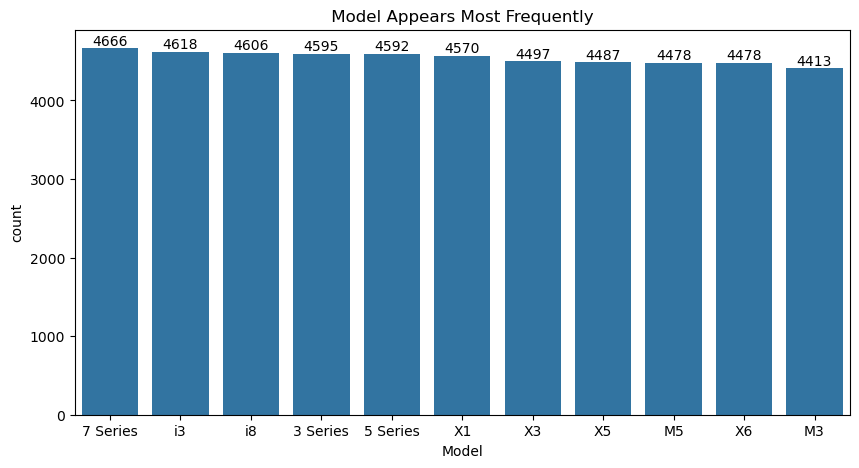

In [283]:
plt.figure(figsize=(10,5))
plt.title(' Model Appears Most Frequently ')
ax = sns.barplot(fre_model)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

Looking at the results in bar chart 
• Top Model : The 7 Series is the most frequent model with 4,666 entries.    
• Close runner-up : the i3(4,618) and i8(4,606) follow very closely behind.   
• Consistency : MMuch like regional chart, the counts across all the these BMW models are remarkably similar, staying within a narrow range between roughly 4,400 and 4,700

In [284]:
# Avg price per model 
avg_per_model = data.groupby('Model')['Price_USD'].mean()
print(avg_per_model)

Model
3 Series    75566.233950
5 Series    75287.844077
7 Series    75570.196742
M3          74841.588715
M5          74474.930996
X1          75262.219037
X3          75016.616856
X5          74708.116782
X6          74434.600491
i3          74800.268081
i8          75366.270951
Name: Price_USD, dtype: float64


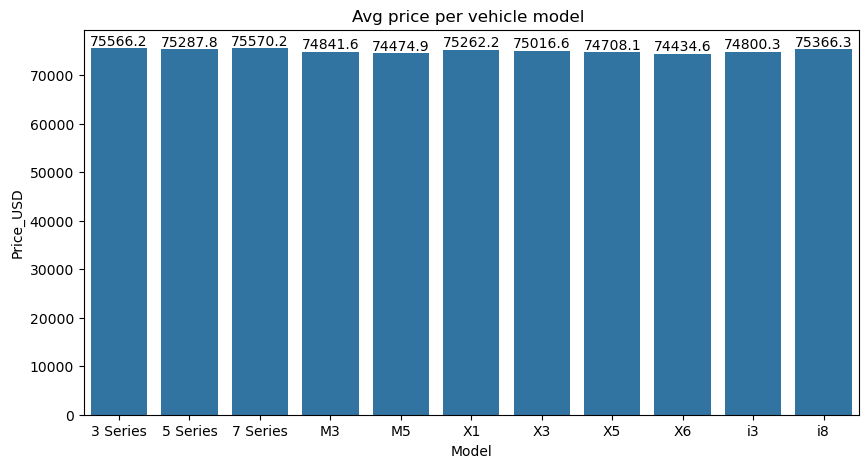

In [285]:
plt.figure(figsize=(10,5))
plt.title('Avg price per vehicle model ')
ax = sns.barplot(avg_per_model)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

This chart shows the average selling price of different BMW models. The prices are relatively close across models, generally ranging between $74,000 and $76,000. The 7 Series and 3 Series appear among the higher-priced models on average, while models like X6 and M5 show slightly lower average prices. Overall, the pricing variation between models is moderate rather than extreme.

In [286]:
# Most expensive model on average
most_exp = avg_per_model.sort_values(ascending=False) 
print(most_exp.head(2))

Model
7 Series    75570.196742
3 Series    75566.233950
Name: Price_USD, dtype: float64


# Year-Based Analysis

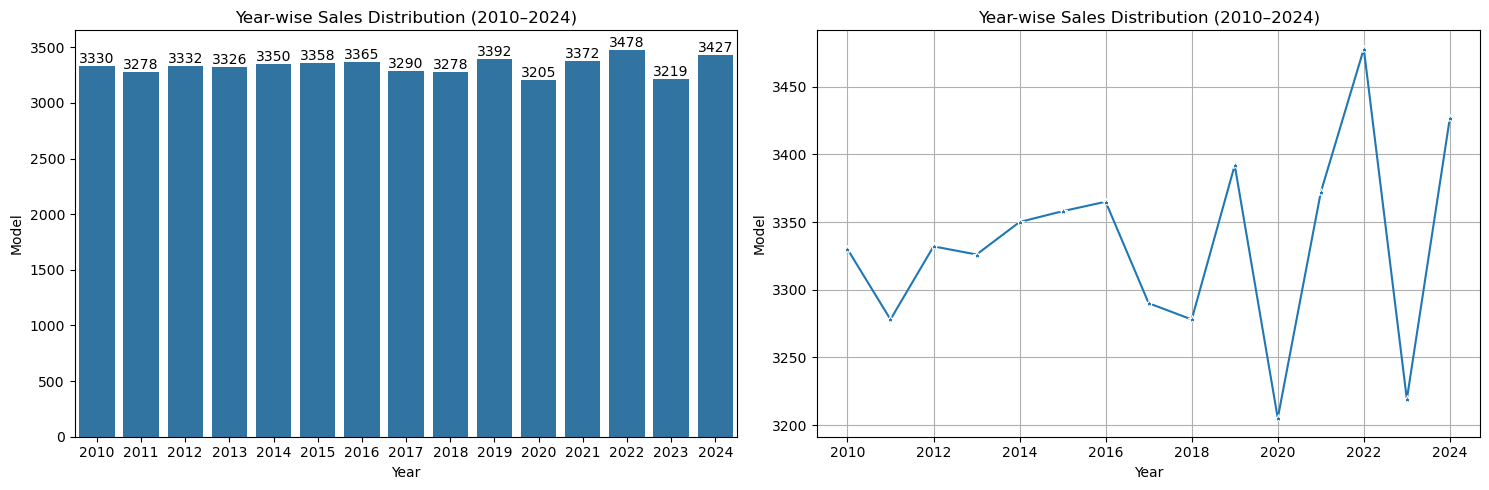

In [287]:
# Year wise sells
year_model = data.groupby('Year')['Model'].count()
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.title("Year-wise Sales Distribution (2010–2024)")
ax= sns.barplot(year_model)
for container in ax.containers:
    ax.bar_label(container)

plt.subplot(1,2,2)
plt.title("Year-wise Sales Distribution (2010–2024)")
sns.lineplot(year_model,marker='*')
plt.grid(True)
plt.tight_layout()
plt.show()

->Insight:
• The bar chart shows year-wise total sales from 2010 to 2024.        
• Sales remain relatively stable between 3200 and 3400 units.      
• A noticeable decline appears in 2020, followed by strong recovery in 2021–2022.     
• The highest sales were recorded in 2022, while 2020 shows the lowest performance.     
• The line chart clearly highlights the upward and downward trends over time.     

->Conclusion:
• The analysis indicates stable long-term sales performance.     
• External factors may have caused the 2020 decline,      
• but the market shows strong recovery and growth momentum afterward.     


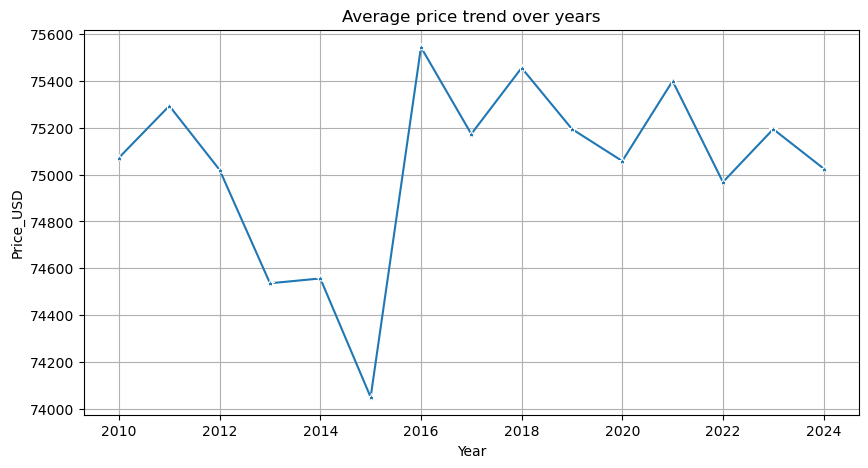

In [288]:
# Average price trend over years
avg_price_year = data.groupby('Year')['Price_USD'].mean()
plt.figure(figsize=(10,5))
plt.title("Average price trend over years")
sns.lineplot(avg_price_year, marker='*')
plt.grid(True)
plt.show()


This chart shows the average BMW price trend from 2010 to 2024. The prices fluctuate slightly over the years, staying within a narrow range around $74,000–$75,600. A noticeable dip appears around 2015, followed by a recovery in 2016. Overall, the trend remains relatively stable without extreme price volatility.

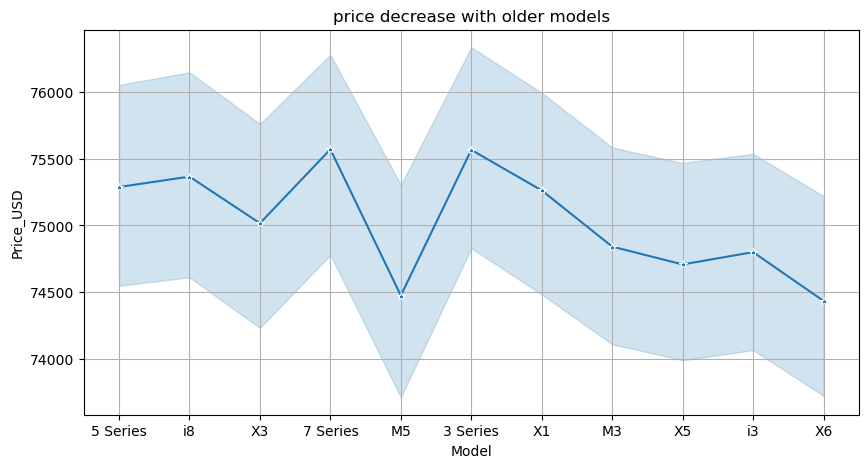

In [289]:
# price decrease with older models
plt.figure(figsize=(10,5))
plt.title('price decrease with older models')
sns.lineplot(data=data, x='Model',y='Price_USD',marker='*')
plt.grid(True)
plt.show()

Prices range roughly between $74,400 and $75,600.

The 7 Series and 3 Series are among the higher-priced models.

The M5 shows a noticeable dip compared to nearby models.

Toward the end (X5, i3, X6), prices slightly decrease, with X6 being one of the lowest.

Overall, the chart suggests a mild downward trend in prices for certain newer or specific models, with small fluctuations across the lineup.

# Fuel Type Analysis 

In [290]:
# fuel type is most common
data['Fuel_Type'].value_counts()

Fuel_Type
Hybrid      12716
Petrol      12550
Electric    12471
Diesel      12263
Name: count, dtype: int64

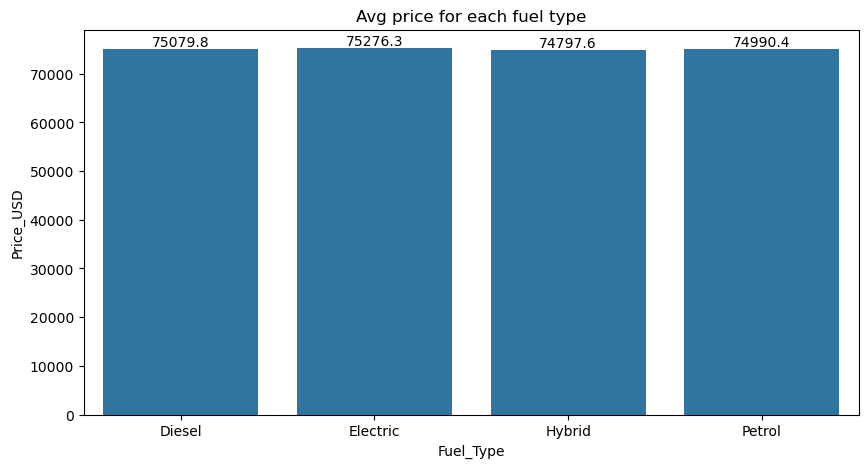

In [291]:
# avg price for each fuel type 
avg_price_fueltype  = data.groupby('Fuel_Type')['Price_USD'].mean()
plt.figure(figsize=(10,5))
plt.title('Avg price for each fuel type')
ax = sns.barplot(avg_price_fueltype)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

Electric cars have the highest average price at around $75,276.

Diesel follows closely at about $75,080.

Petrol averages around $74,990.

Hybrid has the lowest average price at roughly $74,798.

Overall, the price difference between fuel types is small (less than $500), indicating similar pricing across categories.

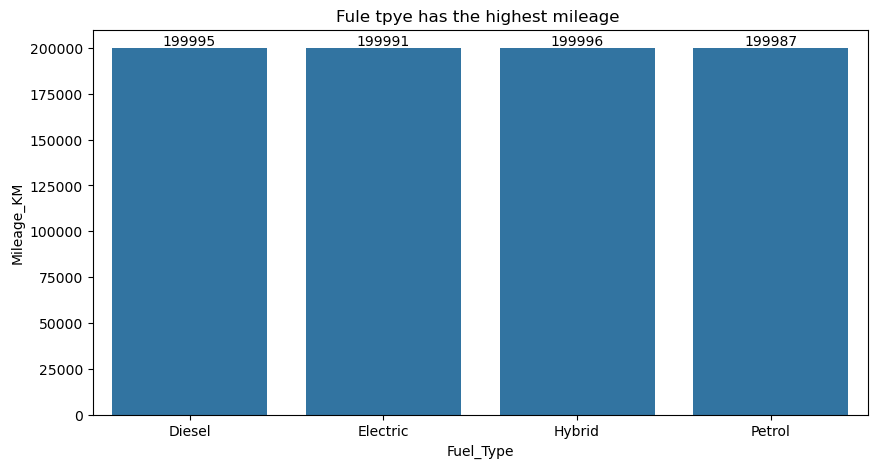

In [292]:
# Fule tpye has the highest mileage 
fuel_highest_mileage = data.groupby('Fuel_Type')['Mileage_KM'].max()
plt.figure(figsize=(10,5))
plt.title('Fule tpye has the highest mileage ')
ax = sns.barplot(fuel_highest_mileage)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

Hybrid has the highest mileage at 199,996 KM.

Diesel is very close at 199,995 KM.

Electric records 199,991 KM.

Petrol has the lowest among them at 199,987 KM.

Overall, the mileage difference is very small (less than 10 KM), meaning all fuel types have nearly similar maximum mileage in this dataset.

# Transmission Analysis

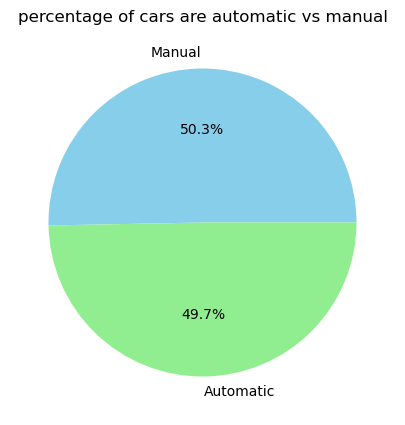

In [293]:
# percentage of cars are automatic vs manual
Transmission_count = data['Transmission'].value_counts()
plt.figure(figsize=(10,5))
plt.pie(Transmission_count, labels=Transmission_count.index, autopct='%1.1f%%',colors=['skyblue','lightgreen'])
plt.title('percentage of cars are automatic vs manual')
plt.show()                                               

Manual cars make up 50.3% of the total.

Automatic cars account for 49.7%.

The difference is very small (only 0.6%), which means the dataset has an almost equal distribution of manual and automatic vehicles.

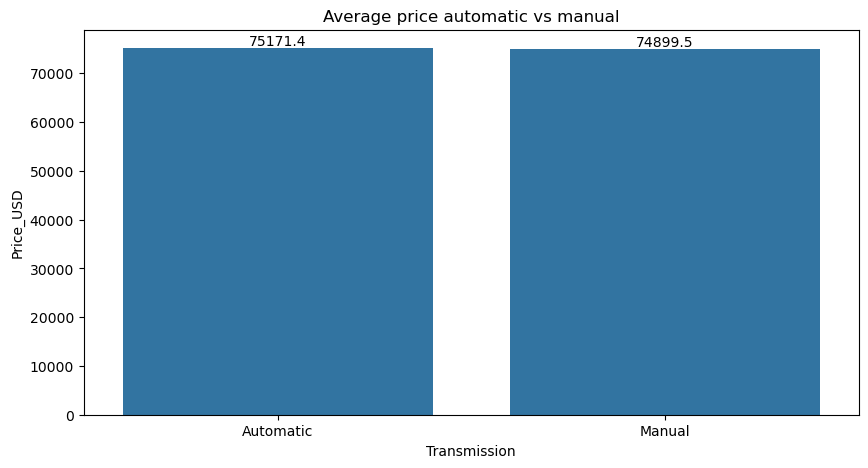

In [294]:
# price difference between automatic and manual cars
diff_trans_price = data.groupby('Transmission')['Price_USD'].mean()
plt.figure(figsize=(10,5))
plt.title('Average price automatic vs manual')
ax = sns.barplot(diff_trans_price)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

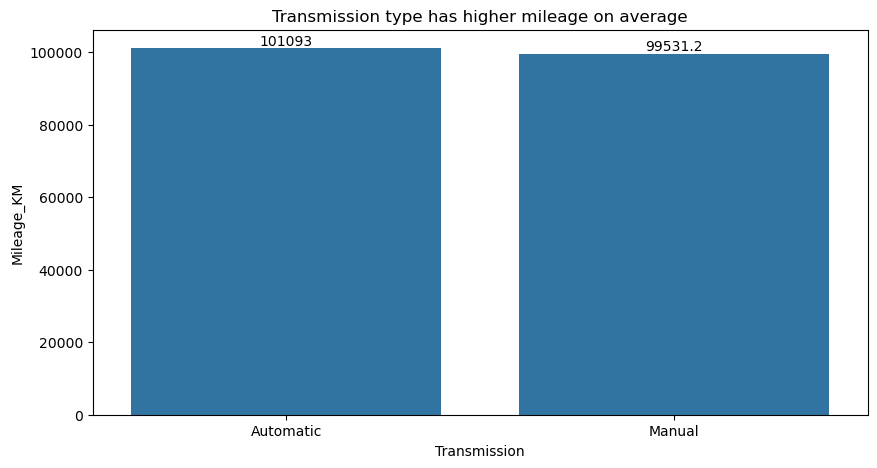

In [295]:
# Transmission type has higher mileage on average 
avg_tra_milege = data.groupby('Transmission')['Mileage_KM'].mean()
plt.figure(figsize=(10,5)) 
plt.title('Transmission type has higher mileage on average')
ax = sns.barplot(avg_tra_milege) 
for container in ax.containers:
    ax.bar_label(container)
plt.show()

# Mileage Analysis 

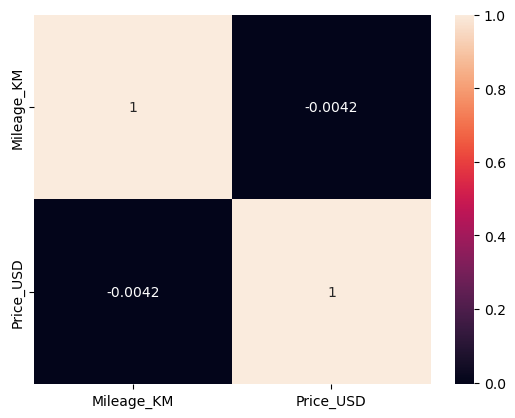

In [296]:
# Relationship between mileage and price 
rel_mil_price = data[['Mileage_KM','Price_USD']].corr()
sns.heatmap(data=data[['Mileage_KM','Price_USD']].corr(),annot=True)
plt.show()

The correlation value is -0.0042, which is very close to zero.

This means there is almost no linear relationship between mileage and price in this dataset.

In simple terms, price does not significantly increase or decrease based on mileage here.

In [297]:
# model has the highest average mileage 
model_highest_avg_mil = data.groupby('Model')['Mileage_KM'].mean()
model_highest_avg_mil.sort_values(ascending=False).head(3)

Model
M5          102342.995757
5 Series    101356.634582
7 Series    100792.165881
Name: Mileage_KM, dtype: float64

# Regions Analysis

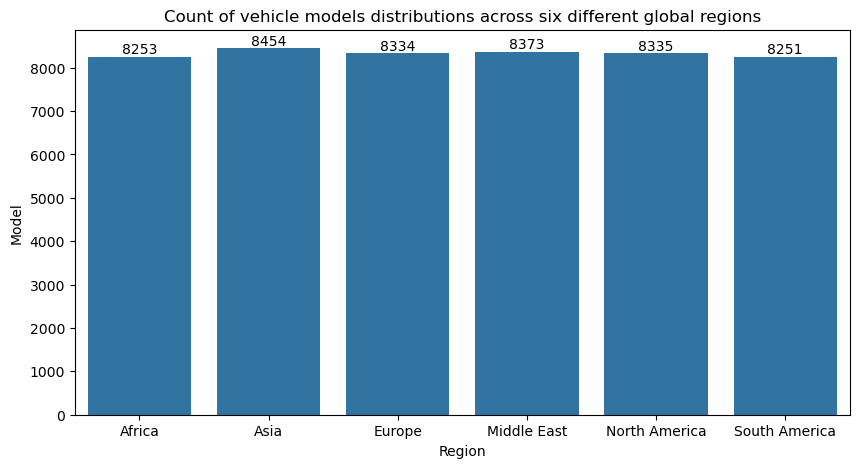

In [298]:
# most sells regions wise
region_model = data.groupby('Region')['Model'].count()
plt.figure(figsize=(10,5))
plt.title('Count of vehicle models distributions across six different global regions')
ax = sns.barplot(region_model)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

 • This bar chart shows a count of vehicle models distributed across six different global regions.       
 • Overall, the data is very evenly distributed, with each region having between roughly 8,250 and 8,450 entries.   
->key Observations 
 • Highest Volume : Asia leads the group with the highest count(8,454).            
 • Lowest Volume : South America has the lowest count(8,251), though the gap between it and Asia is quite small(only 203 units).                
 • Consistency : The most striking feature of this chart is the uniformity. These are no major outliers, suggesting that the dataset is well-balanced    across all geographical areas.


# Conclusion

This analysis highlights the key factors affecting BMW resale prices, including model, year, mileage, transmission, fuel type, and region. Newer cars tend to have higher prices, while increased mileage leads to depreciation. Automatic and certain fuel types show higher average pricing. Overall, the project demonstrates how data analysis can uncover clear pricing trends and support informed decision-making in the used car market.